In [2]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np

2025-06-18 20:05:12.866184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750277112.886620 3848195 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750277112.892612 3848195 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750277112.908056 3848195 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750277112.908073 3848195 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750277112.908075 3848195 computation_placer.cc:177] computation placer alr

In [ ]:
# zip_path = tf.keras.utils.get_file(
#     origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
#     fname='jena_climate_2009_2016.csv.zip',
#     extract=True)
# csv_path, _ = os.path.splitext(zip_path)

13582336/13568290 [==============================] - 0s 0us/step


In [3]:
df = pd.read_csv("common_cad_avg1h.csv")
df

,ts,common_cad_avg1h
0,2024-11-25 18:01:00,570.036987
1,2024-11-25 18:01:15,570.036987
2,2024-11-25 18:01:30,570.036987
3,2024-11-25 18:01:45,570.036987
4,2024-11-25 18:02:00,777.154144
...,...,...
90752,2024-12-11 12:09:00,340.302271
90753,2024-12-11 12:09:15,340.302271
90754,2024-12-11 12:09:30,340.302271
90755,2024-12-11 12:09:45,340.302271


In [4]:
df = df[5::6]
df

,ts,common_cad_avg1h
5,2024-11-25 18:02:15,777.154144
11,2024-11-25 18:03:45,947.016732
17,2024-11-25 18:05:15,986.334294
23,2024-11-25 18:06:45,935.397892
29,2024-11-25 18:08:15,1024.870268
...,...,...
90731,2024-12-11 12:03:45,340.302271
90737,2024-12-11 12:05:15,340.302271
90743,2024-12-11 12:06:45,340.302271
90749,2024-12-11 12:08:15,340.302271


In [4]:
df.index = pd.to_datetime(df['ts'], format='%Y-%m-%d %H:%M:%S')
df[:26]

,ts,common_cad_avg1h
ts,,
2024-11-25 18:01:00,2024-11-25 18:01:00,570.036987
2024-11-25 18:01:15,2024-11-25 18:01:15,570.036987
2024-11-25 18:01:30,2024-11-25 18:01:30,570.036987
2024-11-25 18:01:45,2024-11-25 18:01:45,570.036987
2024-11-25 18:02:00,2024-11-25 18:02:00,777.154144
2024-11-25 18:02:15,2024-11-25 18:02:15,777.154144
2024-11-25 18:02:30,2024-11-25 18:02:30,777.154144
2024-11-25 18:02:45,2024-11-25 18:02:45,777.154144
2024-11-25 18:03:00,2024-11-25 18:03:00,947.016732


<Axes: xlabel='ts'>

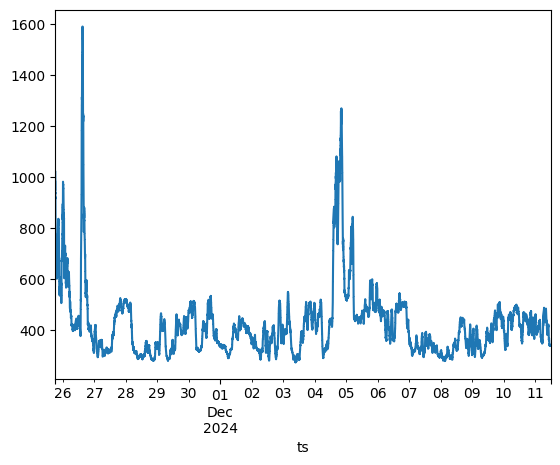

In [5]:
temp = df['common_cad_avg1h']
temp.plot()

In [6]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [7]:
WINDOW_SIZE = 5
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((90752, 5, 1), (90752,))

In [8]:
X_train1, y_train1 = X1[:60000], y1[:60000]
X_val1, y_val1 = X1[60000:65000], y1[60000:65000]
X_test1, y_test1 = X1[65000:], y1[65000:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((60000, 5, 1), (60000,), (5000, 5, 1), (5000,), (25752, 5, 1), (25752,))

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

I0000 00:00:1750277158.946568 3848195 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7267 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:1b:00.0, compute capability: 7.5
I0000 00:00:1750277158.947887 3848195 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 7555 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:1c:00.0, compute capability: 7.5
I0000 00:00:1750277158.948850 3848195 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 420 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:1d:00.0, compute capability: 7.5
I0000 00:00:1750277158.949880 3848195 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 462 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:1e:00.0, compute capability: 7.5
I0000 00:00:1750277158.950854 3848195 gpu_device.c

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cp1 = ModelCheckpoint('model1/model1.h5', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

# history = model1.fit(X1, y1, epochs=100, verbose=1, callbacks=[cp1])

# plt.plot(history.history['loss'])
# plt.plot(history.history['root_mean_squared_error'])
# plt.title('model loss')
# plt.ylabel('loss')
# plt.xlabel('epoch')
# plt.legend(['train', 'test'], loc='upper left')
# plt.show()

In [14]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])

Epoch 1/10


I0000 00:00:1750277339.245783 3849915 cuda_dnn.cc:529] Loaded cuDNN version 90501


1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 217732.1562 - root_mean_squared_error: 466.6061

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 217722.2188 - root_mean_squared_error: 466.5954 - val_loss: 188599.1875 - val_root_mean_squared_error: 434.2801
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 203643.6562 - root_mean_squared_error: 451.2626

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 203642.0469 - root_mean_squared_error: 451.2608 - val_loss: 173917.1562 - val_root_mean_squared_error: 417.0338
Epoch 3/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 189051.0469 - root_mean_squared_error: 434.7880

...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 130308.9141 - root_mean_squared_error: 360.9455 - val_loss: 93669.6094 - val_root_mean_squared_error: 306.0549
Epoch 7/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 110152.9844 - root_mean_squared_error: 331.8216

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 110131.6797 - root_mean_squared_error: 331.7893 - val_loss: 72848.3594 - val_root_mean_squared_error: 269.9044
Epoch 8/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 88054.1172 - root_mean_squared_error: 296.6978

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 88049.3594 - root_mean_squared_error: 296.6897 - val_loss: 53363.3047 - val_root_mean_squared_error: 231.0050
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70479.2969 - root_mean_squared_error: 265.4111

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 70476.6953 - root_mean_squared_error: 265.4061 - val_loss: 36214.7852 - val_root_mean_squared_error: 190.3018
Epoch 10/10
1868/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53653.8359 - root_mean_squared_error: 231.5926

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 53639.5781 - root_mean_squared_error: 231.5615 - val_loss: 22181.4473 - val_root_mean_squared_error: 148.9344


In [15]:
from tensorflow.keras.models import load_model
model1 = load_model('model1/model1.h5')

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,427 (68.08 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [16]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


,Train Predictions,Actuals
0,307.631622,777.154144
1,307.631622,777.154144
2,307.631622,777.154144
3,307.631622,947.016732
4,307.631622,947.016732
...,...,...
59995,307.631622,463.596964
59996,307.631622,463.596964
59997,307.631622,463.596964
59998,307.631622,463.596964


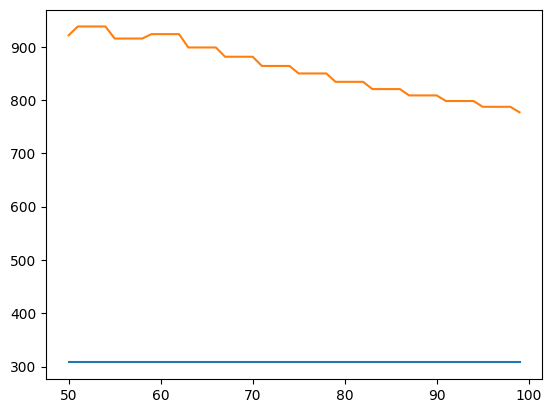

In [17]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'][50:100])
plt.plot(train_results['Actuals'][50:100])

In [18]:
val_predictions = model1.predict(X_val1).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1})
val_results

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Val Predictions,Actuals
0,307.631622,463.846042
1,307.631622,463.846042
2,307.631622,463.846042
3,307.631622,465.833299
4,307.631622,465.833299
...,...,...
4995,307.631561,342.023695
4996,307.631561,342.023695
4997,307.631561,342.023695
4998,307.631561,342.023695


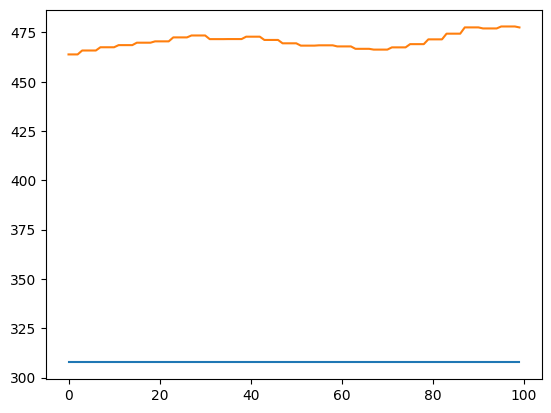

In [21]:
plt.plot(val_results['Val Predictions'][:100])
plt.plot(val_results['Actuals'][:100])

In [22]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})
test_results

805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Test Predictions,Actuals
0,307.631592,343.723523
1,307.631592,343.723523
2,307.631592,343.723523
3,307.631592,344.930456
4,307.631592,344.930456
...,...,...
25747,307.631592,340.302271
25748,307.631592,340.302271
25749,307.631592,340.302271
25750,307.631592,340.302271


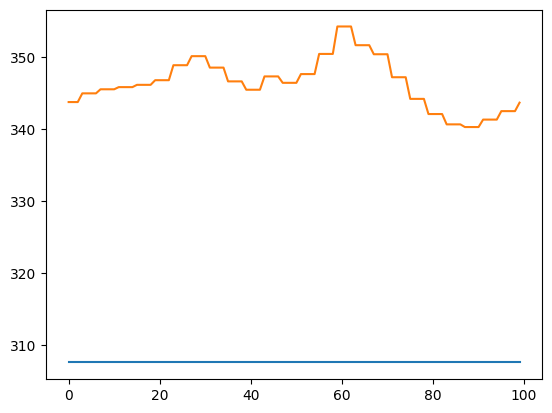

In [23]:
plt.plot(test_results['Test Predictions'][:100])
plt.plot(test_results['Actuals'][:100])

In [24]:
# Split

In [25]:
from sklearn.metrics import mean_squared_error as mse

def plot_predictions1(model, X, y, start=0, end=100):
  predictions = model.predict(X).flatten()
  df = pd.DataFrame(data={'Predictions': predictions, 'Actuals':y})
  plt.plot(df['Predictions'][start:end])
  plt.plot(df['Actuals'][start:end])
  return df, mse(predictions, y)

805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(       Predictions     Actuals
 0       307.631592  343.723523
 1       307.631592  343.723523
 2       307.631592  343.723523
 3       307.631592  344.930456
 4       307.631592  344.930456
 ...            ...         ...
 25747   307.631592  340.302271
 25748   307.631592  340.302271
 25749   307.631592  340.302271
 25750   307.631592  340.302271
 25751   307.631592  340.302271
 
 [25752 rows x 2 columns],
 8070.2840274505525)

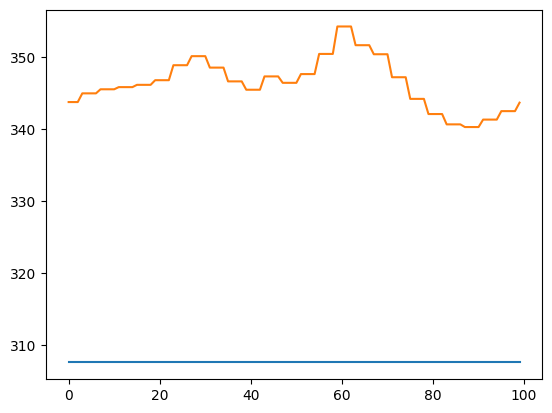

In [26]:
plot_predictions1(model1, X_test1, y_test1)

In [27]:
model2 = Sequential()
model2.add(InputLayer((5, 1)))
model2.add(Conv1D(64, kernel_size=2, activation='relu'))
model2.add(Flatten())
model2.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cp2 = ModelCheckpoint('model2/model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [29]:
model2.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp2])

Epoch 1/10


I0000 00:00:1750277682.413661 3849907 service.cc:152] XLA service 0x7fb3f8002f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750277682.413714 3849907 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.413831 3849907 service.cc:160]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.413837 3849907 service.cc:160]   StreamExecutor device (2): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.413841 3849907 service.cc:160]   StreamExecutor device (3): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.413845 3849907 service.cc:160]   StreamExecutor device (4): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.413848 3849907 service.cc:160]   StreamExecutor device (5): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
I0000 00:00:1750277682.4138

  56/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 217333.7969 - root_mean_squared_error: 465.8077

I0000 00:00:1750277684.410912 3849907 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 39116.1211 - root_mean_squared_error: 176.8584 - val_loss: 3.3831 - val_root_mean_squared_error: 1.8393
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 14.0959 - root_mean_squared_error: 3.7487 - val_loss: 3.3384 - val_root_mean_squared_error: 1.8271
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 13.8470 - root_mean_squared_error: 3.7084 - val_loss: 3.4121 - val_root_mean_squared_error: 1.8472
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 13.9803 - root_mean_squared_error: 3.7332 - val_loss: 3.2655 - val_root_mean_squared_error: 1.8071
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 14.6116 - root_mean_squared_error: 3.8148 - val_loss: 5.4154 - val_root_mean_squared_error: 2.3271
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 12.7458 - root_mean_squared_error: 3.5660 - val_loss: 10.3958 - val_root_mean_squared_error: 3.2243
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━

805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(       Predictions     Actuals
 0       343.112488  343.723523
 1       343.399109  343.723523
 2       343.731201  343.723523
 3       344.120178  344.930456
 4       344.635803  344.930456
 ...            ...         ...
 25747   340.774597  340.302271
 25748   340.774597  340.302271
 25749   340.774597  340.302271
 25750   340.774597  340.302271
 25751   340.774597  340.302271
 
 [25752 rows x 2 columns],
 1.6585213531815233)

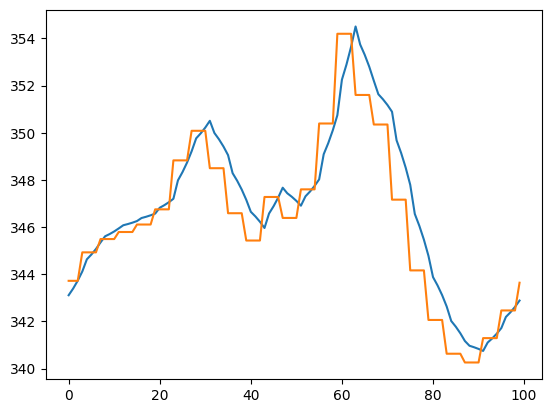

In [30]:
plot_predictions1(model2, X_test1, y_test1)

In [31]:
model3 = Sequential()
model3.add(InputLayer((5, 1)))
model3.add(GRU(64))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1, 'linear'))
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,393 (52.32 KB)

 Trainable params: 13,393 (52.32 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
cp3 = ModelCheckpoint('model3/model3.keras', save_best_only=True)
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [33]:
model3.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp3])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 216525.2031 - root_mean_squared_error: 465.3063 - val_loss: 183023.7500 - val_root_mean_squared_error: 427.8127
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 196480.8594 - root_mean_squared_error: 443.2371 - val_loss: 158656.7500 - val_root_mean_squared_error: 398.3174
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 170214.8750 - root_mean_squared_error: 412.5484 - val_loss: 129689.6016 - val_root_mean_squared_error: 360.1244
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 141621.8125 - root_mean_squared_error: 376.2791 - val_loss: 99028.2266 - val_root_mean_squared_error: 314.6875
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 109888.2969 - root_mean_squared_error: 331.4617 - val_loss: 69477.9141 - val_root_mean_squared_error: 263.5866
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 83078.1719 - root_mean_squared_error: 288.1643 - val_loss: 43401

In [34]:
temp

ts
2024-11-25 18:01:00    570.036987
2024-11-25 18:01:15    570.036987
2024-11-25 18:01:30    570.036987
2024-11-25 18:01:45    570.036987
2024-11-25 18:02:00    777.154144
                          ...    
2024-12-11 12:09:00    340.302271
2024-12-11 12:09:15    340.302271
2024-12-11 12:09:30    340.302271
2024-12-11 12:09:45    340.302271
2024-12-11 12:10:00    340.302271
Name: common_cad_avg1h, Length: 90757, dtype: float64

In [37]:
temp_df = pd.DataFrame({'common_cad_avg1h':temp})
temp_df['Seconds'] = temp_df.index.map(pd.Timestamp.timestamp)
temp_df

,common_cad_avg1h,Seconds
ts,,
2024-11-25 18:01:00,570.036987,1.732558e+09
2024-11-25 18:01:15,570.036987,1.732558e+09
2024-11-25 18:01:30,570.036987,1.732558e+09
2024-11-25 18:01:45,570.036987,1.732558e+09
2024-11-25 18:02:00,777.154144,1.732558e+09
...,...,...
2024-12-11 12:09:00,340.302271,1.733919e+09
2024-12-11 12:09:15,340.302271,1.733919e+09
2024-12-11 12:09:30,340.302271,1.733919e+09


In [38]:
day = 24*60*60
year = (365.2425)*day

temp_df['Day sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Day cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Year sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / year))
temp_df['Year cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / year))
temp_df

,common_cad_avg1h,Seconds,Day sin,Day cos,Year sin,Year cos
ts,,,,,,
2024-11-25 18:01:00,570.036987,1.732558e+09,-0.999990,0.004363,-0.574663,0.818390
2024-11-25 18:01:15,570.036987,1.732558e+09,-0.999985,0.005454,-0.574660,0.818392
2024-11-25 18:01:30,570.036987,1.732558e+09,-0.999979,0.006545,-0.574658,0.818394
2024-11-25 18:01:45,570.036987,1.732558e+09,-0.999971,0.007636,-0.574655,0.818396
2024-11-25 18:02:00,777.154144,1.732558e+09,-0.999962,0.008727,-0.574653,0.818397
...,...,...,...,...,...,...
2024-12-11 12:09:00,340.302271,1.733919e+09,-0.039260,-0.999229,-0.334573,0.942370
2024-12-11 12:09:15,340.302271,1.733919e+09,-0.040350,-0.999186,-0.334571,0.942371
2024-12-11 12:09:30,340.302271,1.733919e+09,-0.041440,-0.999141,-0.334568,0.942372


In [39]:
temp_df = temp_df.drop('Seconds', axis=1)
temp_df

,common_cad_avg1h,Day sin,Day cos,Year sin,Year cos
ts,,,,,
2024-11-25 18:01:00,570.036987,-0.999990,0.004363,-0.574663,0.818390
2024-11-25 18:01:15,570.036987,-0.999985,0.005454,-0.574660,0.818392
2024-11-25 18:01:30,570.036987,-0.999979,0.006545,-0.574658,0.818394
2024-11-25 18:01:45,570.036987,-0.999971,0.007636,-0.574655,0.818396
2024-11-25 18:02:00,777.154144,-0.999962,0.008727,-0.574653,0.818397
...,...,...,...,...,...
2024-12-11 12:09:00,340.302271,-0.039260,-0.999229,-0.334573,0.942370
2024-12-11 12:09:15,340.302271,-0.040350,-0.999186,-0.334571,0.942371
2024-12-11 12:09:30,340.302271,-0.041440,-0.999141,-0.334568,0.942372


In [40]:
def df_to_X_y2(df, window_size=6):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [41]:
X2, y2 = df_to_X_y2(temp_df)
X2.shape, y2.shape

((90751, 6, 5), (90751,))

In [42]:
X2_train, y2_train = X2[:60000], y2[:60000]
X2_val, y2_val = X2[60000:65000], y2[60000:65000]
X2_test, y2_test = X2[65000:], y2[65000:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((60000, 6, 5), (60000,), (5000, 6, 5), (5000,), (25751, 6, 5), (25751,))

In [43]:
temp_training_mean = np.mean(X2_train[:, :, 0])
temp_training_std = np.std(X2_train[:, :, 0])

def preprocess(X):
  X[:, :, 0] = (X[:, :, 0] - temp_training_mean) / temp_training_std
  return X

In [44]:
preprocess(X2_train)
preprocess(X2_val)
preprocess(X2_test)

array([[[-0.6200843 ,  0.22069744,  0.97534232, -0.40599133,
          0.91387693],
        [-0.6200843 ,  0.22176124,  0.975101  , -0.4059886 ,
          0.91387814],
        [-0.6200843 ,  0.22282477,  0.97485851, -0.40598587,
          0.91387935],
        [-0.6200843 ,  0.22388805,  0.97461487, -0.40598314,
          0.91388057],
        [-0.60950919,  0.22495105,  0.97437006, -0.40598041,
          0.91388178],
        [-0.60950919,  0.22601379,  0.9741241 , -0.40597768,
          0.91388299]],

       [[-0.6200843 ,  0.22176124,  0.975101  , -0.4059886 ,
          0.91387814],
        [-0.6200843 ,  0.22282477,  0.97485851, -0.40598587,
          0.91387935],
        [-0.6200843 ,  0.22388805,  0.97461487, -0.40598314,
          0.91388057],
        [-0.60950919,  0.22495105,  0.97437006, -0.40598041,
          0.91388178],
        [-0.60950919,  0.22601379,  0.9741241 , -0.40597768,
          0.91388299],
        [-0.60950919,  0.22707626,  0.97387698, -0.40597495,
          0.9

In [45]:
model4 = Sequential()
model4.add(InputLayer((6, 5)))
model4.add(LSTM(64))
model4.add(Dense(8, 'relu'))
model4.add(Dense(1, 'linear'))

model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,449 (72.07 KB)

 Trainable params: 18,449 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
cp4 = ModelCheckpoint('model4/model4.keras', save_best_only=True)
model4.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [47]:
model4.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=10, callbacks=[cp4])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 214375.3750 - root_mean_squared_error: 462.9644 - val_loss: 176499.5781 - val_root_mean_squared_error: 420.1185
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 190161.6562 - root_mean_squared_error: 436.0241 - val_loss: 148358.1250 - val_root_mean_squared_error: 385.1729
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 160935.1406 - root_mean_squared_error: 401.1139 - val_loss: 116418.9844 - val_root_mean_squared_error: 341.2023
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 128621.5156 - root_mean_squared_error: 358.5713 - val_loss: 83910.1797 - val_root_mean_squared_error: 289.6725
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 96491.4688 - root_mean_squared_error: 310.5561 - val_loss: 53939.0977 - val_root_mean_squared_error: 232.2479
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 68437.7578 - root_mean_squared_error: 261.5174 - val_loss: 29473.

805/805 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(       Predictions     Actuals
 0       339.311401  343.723523
 1       339.383362  343.723523
 2       339.543152  344.930456
 3       339.988342  344.930456
 4       340.466217  344.930456
 ...            ...         ...
 25746   329.227234  340.302271
 25747   329.230957  340.302271
 25748   329.234772  340.302271
 25749   329.238525  340.302271
 25750   329.242310  340.302271
 
 [25751 rows x 2 columns],
 103.68156897250282)

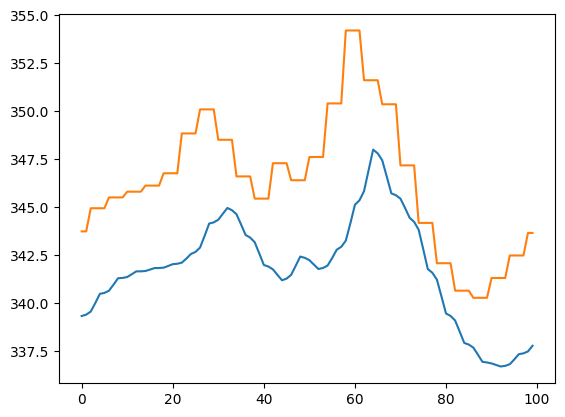

In [48]:
plot_predictions1(model4, X2_test, y2_test)

In [ ]:
p_temp_df = pd.concat([df['p (mbar)'], temp_df], axis=1)
p_temp_df

,p (mbar),Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,996.50,-8.05,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,0.965926,0.258819,0.012916,0.999917
...,...,...,...,...,...,...
2016-12-31 19:10:00,1002.18,-0.98,-0.953717,0.300706,0.006900,0.999976
2016-12-31 20:10:00,1001.40,-1.40,-0.843391,0.537300,0.007617,0.999971
2016-12-31 21:10:00,1001.19,-2.75,-0.675590,0.737277,0.008334,0.999965


In [ ]:
def df_to_X_y3(df, window_size=7):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = [df_as_np[i+window_size][0], df_as_np[i+window_size][1]]
    y.append(label)
  return np.array(X), np.array(y)

In [ ]:
X3, y3 = df_to_X_y3(p_temp_df)
X3.shape, y3.shape

((70084, 7, 6), (70084, 2))

In [ ]:
X3_train, y3_train = X3[:60000], y3[:60000]
X3_val, y3_val = X3[60000:65000], y3[60000:65000]
X3_test, y3_test = X3[65000:], y3[65000:]
X3_train.shape, y3_train.shape, X3_val.shape, y3_val.shape, X3_test.shape, y3_test.shape

((60000, 7, 6), (60000, 2), (5000, 7, 6), (5000, 2), (5084, 7, 6), (5084, 2))

In [ ]:
p_training_mean3 = np.mean(X3_train[:, :, 0])
p_training_std3 = np.std(X3_train[:, :, 0])

temp_training_mean3 = np.mean(X3_train[:, :, 1])
temp_training_std3 = np.std(X3_train[:, :, 1])

def preprocess3(X):
  X[:, :, 0] = (X[:, :, 0] - p_training_mean3) / p_training_std3
  X[:, :, 1] = (X[:, :, 1] - temp_training_mean3) / temp_training_std3
  return X

def preprocess_output(y):
  y[:, 0] = (y[:, 0] - p_training_mean3) / p_training_std3
  y[:, 1] = (y[:, 1] - temp_training_mean3) / temp_training_std3
  return y

In [ ]:
preprocess3(X3_train)
preprocess3(X3_val)
preprocess3(X3_test)

array([[[-1.07355644e+00,  1.04009390e+00, -9.65925826e-01,
          2.58819045e-01,  5.22877889e-01, -8.52407598e-01],
        [-1.00807435e+00,  9.90728707e-01, -8.66025404e-01,
          5.00000000e-01,  5.22266764e-01, -8.52782169e-01],
        [-9.51080673e-01,  8.49685305e-01, -7.07106781e-01,
          7.07106781e-01,  5.21655371e-01, -8.53156301e-01],
        ...,
        [-8.80748054e-01,  6.66328883e-01, -2.58819045e-01,
          9.65925826e-01,  5.20431780e-01, -8.53903251e-01],
        [-8.29817537e-01,  5.37039098e-01, -7.16474371e-12,
          1.00000000e+00,  5.19819584e-01, -8.54276068e-01],
        [-8.01927015e-01,  4.74744929e-01,  2.58819045e-01,
          9.65925826e-01,  5.19207120e-01, -8.54648446e-01]],

       [[-1.00807435e+00,  9.90728707e-01, -8.66025404e-01,
          5.00000000e-01,  5.22266764e-01, -8.52782169e-01],
        [-9.51080673e-01,  8.49685305e-01, -7.07106781e-01,
          7.07106781e-01,  5.21655371e-01, -8.53156301e-01],
        [-9.14701

In [ ]:
preprocess_output(y3_train)
preprocess_output(y3_val)
preprocess_output(y3_test)

array([[-0.7934386 ,  0.41245076],
       [-0.76312281,  0.35368268],
       [-0.72189335,  0.32312327],
       ...,
       [ 1.48145784, -1.43051636],
       [ 1.41597574, -1.44697142],
       [ 1.35049365, -1.56920903]])

In [ ]:
model5 = Sequential()
model5.add(InputLayer((7, 6)))
model5.add(LSTM(64))
model5.add(Dense(8, 'relu'))
model5.add(Dense(2, 'linear'))

model5.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_3 (LSTM)                (None, 64)                18176     
_________________________________________________________________
dense_12 (Dense)             (None, 8)                 520       
_________________________________________________________________
dense_13 (Dense)             (None, 2)                 18        
Total params: 18,714
Trainable params: 18,714
Non-trainable params: 0
_________________________________________________________________


In [ ]:
cp5 = ModelCheckpoint('model5/', save_best_only=True)
model5.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model5.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp5])

Epoch 1/10
 375/1875 [=====>........................] - ETA: 8s - loss: 0.0713 - root_mean_squared_error: 0.2670

KeyboardInterrupt: ignored

In [ ]:
def plot_predictions2(model, X, y, start=0, end=100):
  predictions = model.predict(X)
  p_preds, temp_preds = predictions[:, 0], predictions[:, 1]
  p_actuals, temp_actuals = y[:, 0], y[:, 1]
  df = pd.DataFrame(data={'Temperature Predictions': temp_preds,
                          'Temperature Actuals':temp_actuals,
                          'Pressure Predictions': p_preds,
                          'Pressure Actuals': p_actuals
                          })
  plt.plot(df['Temperature Predictions'][start:end])
  plt.plot(df['Temperature Actuals'][start:end])
  plt.plot(df['Pressure Predictions'][start:end])
  plt.plot(df['Pressure Actuals'][start:end])
  return df

,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.497261,0.412451,-0.939157,-0.793439
1,0.473668,0.353683,-0.892772,-0.763123
2,0.458037,0.323123,-0.859892,-0.721893
3,0.467024,0.250251,-0.840133,-0.652773
4,0.488601,0.254952,-0.823547,-0.652773
...,...,...,...,...
5079,-0.917703,-1.222477,1.712903,1.601508
5080,-0.988455,-1.271843,1.652463,1.506923
5081,-1.087464,-1.430516,1.593468,1.481458
5082,-1.219868,-1.446971,1.541024,1.415976


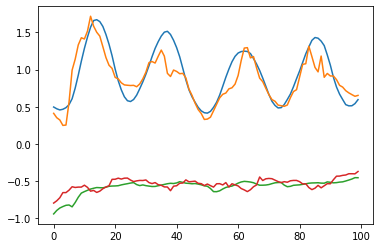

In [ ]:
plot_predictions2(model5, X3_test, y3_test)

In [ ]:
def postprocess_temp(arr):
  arr = (arr*temp_training_std3) + temp_training_mean3
  return arr

def postprocess_p(arr):
  arr = (arr*p_training_std3) + p_training_mean3
  return arr

In [ ]:
def get_predictions_postprocessed(model, X, y):
  predictions = model.predict(X)
  p_preds, temp_preds = postprocess_p(predictions[:, 0]), postprocess_temp(predictions[:, 1])
  p_actuals, temp_actuals = postprocess_p(y[:, 0]), postprocess_temp(y[:, 1])
  df = pd.DataFrame(data={'Temperature Predictions': temp_preds,
                          'Temperature Actuals':temp_actuals,
                          'Pressure Predictions': p_preds,
                          'Pressure Actuals': p_actuals
                          })
  return df

In [ ]:
post_processed_df = get_predictions_postprocessed(model5, X3_test, y3_test)
post_processed_df

,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,13.651567,12.93,981.228333,982.43
1,13.450840,12.43,981.610901,982.68
2,13.317848,12.17,981.882019,983.02
3,13.394308,11.55,982.044983,983.59
4,13.577888,11.59,982.181763,983.59
...,...,...,...,...
5079,1.613030,-0.98,1003.098633,1002.18
5080,1.011069,-1.40,1002.600220,1001.40
5081,0.168693,-2.75,1002.113708,1001.19
5082,-0.957798,-2.89,1001.681274,1000.65


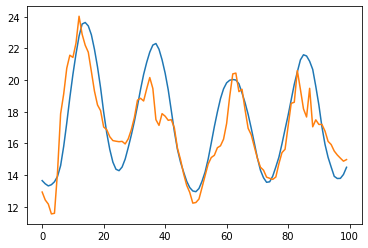

In [ ]:
start, end = 0, 100
plt.plot(post_processed_df['Temperature Predictions'][start:end])
plt.plot(post_processed_df['Temperature Actuals'][start:end])

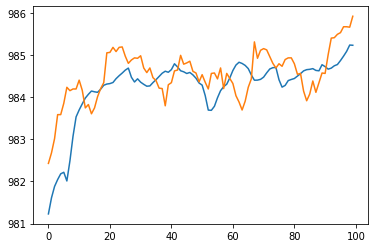

In [ ]:
plt.plot(post_processed_df['Pressure Predictions'][start:end])
plt.plot(post_processed_df['Pressure Actuals'][start:end])

In [ ]:
model6 = Sequential()
model6.add(InputLayer((7, 6)))
model6.add(LSTM(32, return_sequences=True))
model6.add(LSTM(16))
model6.add(Dense(8, 'relu'))
model6.add(Dense(2, 'linear'))

model6.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_4 (LSTM)                (None, 7, 32)             4992      
_________________________________________________________________
lstm_5 (LSTM)                (None, 16)                3136      
_________________________________________________________________
dense_14 (Dense)             (None, 8)                 136       
_________________________________________________________________
dense_15 (Dense)             (None, 2)                 18        
Total params: 8,282
Trainable params: 8,282
Non-trainable params: 0
_________________________________________________________________


In [ ]:
cp6 = ModelCheckpoint('model6/', save_best_only=True)
model6.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model6.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp6])

Epoch 1/10
 131/1875 [=>............................] - ETA: 12s - loss: 0.8951 - root_mean_squared_error: 0.9461

KeyboardInterrupt: ignored

In [ ]:
model7 = Sequential()
model7.add(InputLayer((7, 6)))
model7.add(Conv1D(64, kernel_size=2, activation='relu'))
model7.add(Flatten())
model7.add(Dense(8, 'relu'))
model7.add(Dense(2, 'linear'))
model7.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_3 (Conv1D)            (None, 6, 64)             832       
_________________________________________________________________
flatten_3 (Flatten)          (None, 384)               0         
_________________________________________________________________
dense_18 (Dense)             (None, 8)                 3080      
_________________________________________________________________
dense_19 (Dense)             (None, 2)                 18        
Total params: 3,930
Trainable params: 3,930
Non-trainable params: 0
_________________________________________________________________


In [ ]:
cp7 = ModelCheckpoint('model6/', save_best_only=True)
model7.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model7.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp7])

Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0984 - root_mean_squared_error: 0.3136 - val_loss: 0.0216 - val_root_mean_squared_error: 0.1471
INFO:tensorflow:Assets written to: model6/assets


INFO:tensorflow:Assets written to: model6/assets


Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0143 - root_mean_squared_error: 0.1196 - val_loss: 0.0098 - val_root_mean_squared_error: 0.0988
INFO:tensorflow:Assets written to: model6/assets


INFO:tensorflow:Assets written to: model6/assets


Epoch 3/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0092 - root_mean_squared_error: 0.0959 - val_loss: 0.0072 - val_root_mean_squared_error: 0.0849
INFO:tensorflow:Assets written to: model6/assets


...

INFO:tensorflow:Assets written to: model6/assets


Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0059 - root_mean_squared_error: 0.0768 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0689
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0057 - root_mean_squared_error: 0.0757 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0670
INFO:tensorflow:Assets written to: model6/assets


INFO:tensorflow:Assets written to: model6/assets


Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0056 - root_mean_squared_error: 0.0749 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0661
INFO:tensorflow:Assets written to: model6/assets


INFO:tensorflow:Assets written to: model6/assets
